# Siamese LSTM Baseline Model — Smart Job Search Using Deep Learning

This notebook builds the baseline model for semantic resume-to-job matching using a Siamese Bidirectional LSTM architecture trained from scratch (no pretrained embeddings). The purpose of this model is to establish a performance baseline that will later be compared against a finetuned Sentence Transformer.

**Architecture:**
- Embedding layer (128 dim) → 2 layer Bidirectional LSTM (hidden 128, output 256 dim) → Cosine Similarity
- Vocabulary: 20,000 words, sequence length: 300 tokens
- Dropout: 0.3, gradient clipping: 1.0

**Training setup:**
- ~55,000 resume job pairs with labels: 0.1 (unrelated), 0.5 (related), 0.9 (same category)
- MSE loss, Adam optimizer (lr=0.001), ReduceLROnPlateau scheduler
- 20 epochs, batch size 64, data split 80/10/10

**Result:** 65.1% test accuracy, MSE 0.0936

In [1]:
# Install & Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import os
 
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [3]:

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Data
Loads the two primary datasets:
- **LiveCareer resumes** — 2,484 resumes across 24 job categories
- **LinkedIn job postings** — 101,492 filtered postings across the same 24 categories

Both datasets share identical category labels, enabling direct pairing for training.

In [ ]:
# Load Data
RESUME_PATH = 'live_resume/Resume/Resume.csv'
JOB_PATH = 'linkedin_job/filtered_job_postings.csv'

# Load datasets
resume_df = pd.read_csv(RESUME_PATH)
job_df = pd.read_csv(JOB_PATH)

# Column names (from your EDA notebook)
job_text_col = 'job_description'
job_cat_col = 'Category'

print(f"Resumes loaded: {len(resume_df)} rows")
print(f"Jobs loaded: {len(job_df)} rows")
print(f"\nResume categories ({resume_df['Category'].nunique()}): {sorted(resume_df['Category'].unique())}")
print(f"Job categories ({job_df[job_cat_col].nunique()}): {sorted(job_df[job_cat_col].unique())}")

Resumes loaded: 2484 rows
Jobs loaded: 101492 rows

Resume categories (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Job categories (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


## Text Preprocessing
Cleans raw resume and job description text by:
- Removing HTML tags, URLs, emails, and special characters
- Lowercasing and tokenizing with NLTK
- Removing English stop words
- Keeping only tokens longer than 2 characters

Clean text is stored in a new column for vocabulary building and model input.

In [ ]:
# Text Preprocessing
stop_words = set(stopwords.words('english'))
 
def clean_text(text):
    """Clean and preprocess text for the LSTM model."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)       # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text) # Remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)        # Remove emails
    text = re.sub(r'[^a-z\s]', ' ', text)       # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # Normalize whitespace
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)
 
print("Cleaning resume texts...")
resume_df['clean_text'] = resume_df['Resume_str'].apply(clean_text)
 
print("Cleaning job description texts...")
job_df['clean_text'] = job_df[job_text_col].apply(clean_text)
 
# Drop any rows with empty text after cleaning
resume_df = resume_df[resume_df['clean_text'].str.len() > 0].reset_index(drop=True)
job_df = job_df[job_df['clean_text'].str.len() > 0].reset_index(drop=True)
 
print(f"\nAfter cleaning — Resumes: {len(resume_df)}, Jobs: {len(job_df)}")
print(f"Sample cleaned resume (first 200 chars): {resume_df['clean_text'].iloc[0][:200]}")
print(f"Sample cleaned job (first 200 chars): {job_df['clean_text'].iloc[0][:200]}")

Cleaning resume texts...
Cleaning job description texts...

After cleaning — Resumes: 2483, Jobs: 101485
Sample cleaned resume (first 200 chars): administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri
Sample cleaned job (first 200 chars): national exemplar accepting applications assistant restaurant manager offer highly competitive wages healthcare paid time complimentary dining privileges bonus opportunities serious professional long 


## Build Vocabulary
Constructs a word to index mapping from the combined resume and job text:
- **Vocabulary size:** Top 20,000 most frequent words
- **Sequence length:** 300 tokens (shorter texts are padded, longer texts are truncated)
- Special tokens: `<PAD>` (index 0) and `<UNK>` (index 1) for padding and unknown words

Texts are converted to integer sequences using this vocabulary for input to the LSTM.

In [ ]:
# Build Vocabulary
MAX_VOCAB_SIZE = 20000   # Top 20k most common words
MAX_SEQ_LENGTH = 300    # Truncate/pad texts to this length
 
# Combine all texts to build vocabulary
all_texts = pd.concat([resume_df['clean_text'], job_df['clean_text']])
word_counts = Counter()
for text in all_texts:
    word_counts.update(text.split())
 
print(f"Total unique words: {len(word_counts)}")
 
# Build word-to-index mapping (reserve 0=padding, 1=unknown)
most_common = word_counts.most_common(MAX_VOCAB_SIZE - 2)
word2idx = {'<PAD>': 0, '<UNK>': 1}
for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i
 
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size: {VOCAB_SIZE}")
 
def text_to_indices(text, max_len=MAX_SEQ_LENGTH):
    """Convert text string to padded list of word indices."""
    tokens = text.split()[:max_len]
    indices = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    # Pad to max_len
    indices += [0] * (max_len - len(indices))
    return indices

Total unique words: 288120
Vocabulary size: 20000


## Define Related Categories and Generate Training Pairs
Manually defines which job categories are semantically related (e.g., IT ↔ Engineering, Finance ↔ Accountant). Each resume-job pair is assigned a similarity label:
- **0.9** — same category (strong match)
- **0.5** — related categories (transferable skills)
- **0.1** — unrelated categories (no match)

Approximately 55,000 pairs are generated with balanced representation across all three label types, then split 80/10/10 into train, validation, and test sets.

In [7]:
# Define Related Categories
# Categories that share transferable skills get similarity = 0.5
# Same category = 0.9, Unrelated = 0.1
 
RELATED_CATEGORIES = {
    'Information-Technology': ['Engineering', 'Digital-Media', 'BPO', 'Consultant'],
    'Engineering': ['Information-Technology', 'Automobile', 'Aviation', 'Construction'],
    'Healthcare': ['Fitness', 'Agriculture'],
    'Finance': ['Accountant', 'Banking', 'Business-Development', 'Consultant'],
    'Accountant': ['Finance', 'Banking', 'Business-Development'],
    'Banking': ['Finance', 'Accountant', 'Business-Development'],
    'Sales': ['Business-Development', 'Public-Relations', 'Advocate', 'Consultant'],
    'Business-Development': ['Sales', 'Finance', 'Consultant', 'Public-Relations'],
    'Arts': ['Designer', 'Apparel', 'Digital-Media', 'Public-Relations'],
    'Designer': ['Arts', 'Apparel', 'Digital-Media'],
    'Digital-Media': ['Arts', 'Designer', 'Information-Technology', 'Public-Relations'],
    'Apparel': ['Arts', 'Designer'],
    'Aviation': ['Engineering', 'Automobile'],
    'Automobile': ['Engineering', 'Aviation', 'Construction'],
    'Construction': ['Engineering', 'Automobile'],
    'Teacher': ['Consultant', 'Public-Relations', 'HR'],
    'HR': ['Business-Development', 'Consultant', 'Public-Relations', 'Teacher'],
    'Advocate': ['Sales', 'Public-Relations', 'Consultant'],
    'Consultant': ['Business-Development', 'Information-Technology', 'Finance', 'HR'],
    'Chef': ['Agriculture'],
    'Agriculture': ['Chef', 'Healthcare', 'Fitness'],
    'Fitness': ['Healthcare', 'Agriculture'],
    'BPO': ['Information-Technology', 'Sales', 'HR'],
    'Public-Relations': ['Sales', 'HR', 'Arts', 'Digital-Media', 'Business-Development'],
}
 
def get_similarity_label(cat1, cat2):
    """Return similarity score based on category relationship."""
    if cat1 == cat2:
        return 0.9
    elif cat2 in RELATED_CATEGORIES.get(cat1, []):
        return 0.5
    else:
        return 0.1

In [ ]:
# Generate Training Pairs (50,000+)
print("Generating training pairs...")
 
# Group texts by category
resume_by_cat = resume_df.groupby('Category')['clean_text'].apply(list).to_dict()
job_by_cat = job_df.groupby(job_cat_col)['clean_text'].apply(list).to_dict()
 
# Get overlapping categories
categories = sorted(set(resume_by_cat.keys()) & set(job_by_cat.keys()))
print(f"Overlapping categories: {len(categories)}")
 
pairs = []  # Each entry: (resume_text, job_text, similarity_label)
 
# --- Same category pairs (target: ~20,000) ---
TARGET_SAME = 20000
same_per_cat = TARGET_SAME // len(categories)
for cat in categories:
    resumes = resume_by_cat[cat]
    jobs = job_by_cat[cat]
    for _ in range(same_per_cat):
        r = random.choice(resumes)
        j = random.choice(jobs)
        pairs.append((r, j, 0.9))
 
# --- Related category pairs (target: ~15,000) ---
TARGET_RELATED = 15000
related_pairs_pool = []
for cat in categories:
    related_cats = [c for c in RELATED_CATEGORIES.get(cat, []) if c in job_by_cat]
    for rel_cat in related_cats:
        related_pairs_pool.append((cat, rel_cat))
 
if related_pairs_pool:
    rel_per_pair = max(1, TARGET_RELATED // len(related_pairs_pool))
    for res_cat, job_cat in related_pairs_pool:
        resumes = resume_by_cat[res_cat]
        jobs = job_by_cat[job_cat]
        for _ in range(rel_per_pair):
            r = random.choice(resumes)
            j = random.choice(jobs)
            pairs.append((r, j, 0.5))
 
# --- Unrelated category pairs (target: ~20,000) ---
TARGET_UNRELATED = 20000
unrelated_count = 0
while unrelated_count < TARGET_UNRELATED:
    cat1 = random.choice(categories)
    cat2 = random.choice(categories)
    if cat1 != cat2 and cat2 not in RELATED_CATEGORIES.get(cat1, []):
        r = random.choice(resume_by_cat[cat1])
        j = random.choice(job_by_cat[cat2])
        pairs.append((r, j, 0.1))
        unrelated_count += 1
 
random.shuffle(pairs)
print(f"\nTotal training pairs generated: {len(pairs)}")
 
# Distribution check
labels = [p[2] for p in pairs]
print(f"  Same category (0.9):    {labels.count(0.9)}")
print(f"  Related category (0.5): {labels.count(0.5)}")
print(f"  Unrelated (0.1):        {labels.count(0.1)}")

Generating training pairs...
Overlapping categories: 24

Total training pairs generated: 54992
  Same category (0.9):    19992
  Related category (0.5): 15000
  Unrelated (0.1):        20000


## PyTorch Dataset and DataLoaders
Wraps the generated pairs into a custom PyTorch Dataset class that:
- Converts text sequences to padded/truncated integer tensors
- Returns (resume_tensor, job_tensor, similarity_label) tuples
- Creates DataLoaders with batch size 64 for train, validation, and test splits

In [ ]:
# Create PyTorch Dataset & DataLoaders
class ResumJobPairDataset(Dataset):
    """Dataset of (resume, job_description) pairs with similarity labels."""
 
    def __init__(self, pairs, max_len=MAX_SEQ_LENGTH):
        self.pairs = pairs
        self.max_len = max_len
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        resume_text, job_text, label = self.pairs[idx]
        resume_ids = text_to_indices(resume_text, self.max_len)
        job_ids = text_to_indices(job_text, self.max_len)
        return (
            torch.tensor(resume_ids, dtype=torch.long),
            torch.tensor(job_ids, dtype=torch.long),
            torch.tensor(label, dtype=torch.float)
        )
 
# Split: 80% train, 10% validation, 10% test
train_pairs, temp_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED)
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=SEED)
 
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")
 
BATCH_SIZE = 64
 
train_dataset = ResumJobPairDataset(train_pairs)
val_dataset = ResumJobPairDataset(val_pairs)
test_dataset = ResumJobPairDataset(test_pairs)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train: 43993 | Val: 5499 | Test: 5500


## Siamese LSTM Model Architecture
Defines the model in two parts:

**LSTMEncoder** (shared weights between both branches):
- Embedding layer: vocab_size → 128 dimensions
- 2 layer Bidirectional LSTM: hidden size 128, output 256 dim per direction
- Uses the final hidden state as the text representation

**SiameseLSTM** (full model):
- Passes both resume and job description through the same LSTMEncoder
- Computes cosine similarity between the two output embeddings
- Output is a similarity score between -1 and 1

In [ ]:
# Define Siamese LSTM Model
class LSTMEncoder(nn.Module):
    """LSTM-based text encoder — shared between both branches of the Siamese network."""
 
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(LSTMEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))           # (batch, seq_len, embed_dim)
        output, (hidden, _) = self.lstm(embedded)            # hidden: (num_layers*2, batch, hidden_dim)
        # Concatenate final forward and backward hidden states
        hidden_fwd = hidden[-2]   # Last layer forward
        hidden_bwd = hidden[-1]   # Last layer backward
        combined = torch.cat((hidden_fwd, hidden_bwd), dim=1)  # (batch, hidden_dim*2)
        return self.dropout(combined)
 
 
class SiameseLSTM(nn.Module):
    """
    Siamese network with shared LSTM encoder.
    Produces similarity score between resume and job description.
    """
 
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.3):
        super(SiameseLSTM, self).__init__()
        self.encoder = LSTMEncoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)
 
    def forward(self, input1, input2):
        # Encode both texts through the SAME encoder (shared weights)
        embed1 = self.encoder(input1)   # (batch, hidden_dim*2)
        embed2 = self.encoder(input2)   # (batch, hidden_dim*2)
        # Cosine similarity
        similarity = nn.functional.cosine_similarity(embed1, embed2, dim=1)
        return similarity
 
 
# Initialize model
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3
 
model = SiameseLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
 
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Model Architecture:
SiameseLSTM(
  (encoder): LSTMEncoder(
    (embedding): Embedding(20000, 128, padding_idx=0)
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

Total parameters: 3,219,456
Trainable parameters: 3,219,456


## Training
Trains the Siamese LSTM for 20 epochs with:
- **Loss:** MSE between predicted cosine similarity and target labels
- **Optimizer:** Adam (lr=0.001)
- **Scheduler:** ReduceLROnPlateau (patience=2, factor=0.5) — reduces learning rate when validation loss plateaus
- **Gradient clipping:** Max norm 1.0 to prevent exploding gradients
- **Early saving:** Best model checkpoint saved based on lowest validation loss

In [ ]:
# Training Loop
EPOCHS = 20
LEARNING_RATE = 0.001
 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
 
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
 
def compute_accuracy(predictions, labels, threshold=0.15):
    """
    Accuracy: predicted similarity within 'threshold' of true label.
    For 3-class bucketing (0.1, 0.5, 0.9), we also compute bucket accuracy.
    """
    # Continuous accuracy (within threshold)
    correct = (torch.abs(predictions - labels) < threshold).float().mean()
 
    # Bucket accuracy: round predictions to nearest label (0.1, 0.5, 0.9)
    buckets = torch.tensor([0.1, 0.5, 0.9], device=predictions.device)
    pred_buckets = buckets[torch.argmin(torch.abs(predictions.unsqueeze(1) - buckets.unsqueeze(0)), dim=1)]
    label_buckets = buckets[torch.argmin(torch.abs(labels.unsqueeze(1) - buckets.unsqueeze(0)), dim=1)]
    bucket_acc = (pred_buckets == label_buckets).float().mean()
 
    return bucket_acc.item()
 
print("Starting training...\n")
best_val_loss = float('inf')
 
for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_train_loss = 0
    epoch_train_preds = []
    epoch_train_labels = []
 
    for batch_idx, (resume_ids, job_ids, labels) in enumerate(train_loader):
        resume_ids = resume_ids.to(device)
        job_ids = job_ids.to(device)
        labels = labels.to(device)
 
        optimizer.zero_grad()
        predictions = model(resume_ids, job_ids)
        loss = criterion(predictions, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
 
        epoch_train_loss += loss.item()
        epoch_train_preds.append(predictions.detach())
        epoch_train_labels.append(labels.detach())
 
    avg_train_loss = epoch_train_loss / len(train_loader)
    all_train_preds = torch.cat(epoch_train_preds)
    all_train_labels = torch.cat(epoch_train_labels)
    train_acc = compute_accuracy(all_train_preds, all_train_labels)
 
    # --- Validation ---
    model.eval()
    epoch_val_loss = 0
    epoch_val_preds = []
    epoch_val_labels = []
 
    with torch.no_grad():
        for resume_ids, job_ids, labels in val_loader:
            resume_ids = resume_ids.to(device)
            job_ids = job_ids.to(device)
            labels = labels.to(device)
 
            predictions = model(resume_ids, job_ids)
            loss = criterion(predictions, labels)
 
            epoch_val_loss += loss.item()
            epoch_val_preds.append(predictions)
            epoch_val_labels.append(labels)
 
    avg_val_loss = epoch_val_loss / len(val_loader)
    all_val_preds = torch.cat(epoch_val_preds)
    all_val_labels = torch.cat(epoch_val_labels)
    val_acc = compute_accuracy(all_val_preds, all_val_labels)
 
    # Step scheduler
    scheduler.step(avg_val_loss)
 
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'siamese_lstm_best.pth')
 
    # Record metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
 
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}")
 
print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

Starting training...

Epoch  1/20 | Train Loss: 0.0673 | Train Acc: 0.5296 | Val Loss: 0.1019 | Val Acc: 0.5466 | LR: 0.001000
Epoch  2/20 | Train Loss: 0.0647 | Train Acc: 0.5465 | Val Loss: 0.1024 | Val Acc: 0.5292 | LR: 0.001000
Epoch  3/20 | Train Loss: 0.0625 | Train Acc: 0.5557 | Val Loss: 0.0983 | Val Acc: 0.5985 | LR: 0.001000
Epoch  4/20 | Train Loss: 0.0611 | Train Acc: 0.5635 | Val Loss: 0.1001 | Val Acc: 0.5319 | LR: 0.001000
Epoch  5/20 | Train Loss: 0.0586 | Train Acc: 0.5764 | Val Loss: 0.1016 | Val Acc: 0.5154 | LR: 0.001000
Epoch  6/20 | Train Loss: 0.0574 | Train Acc: 0.5855 | Val Loss: 0.0971 | Val Acc: 0.6105 | LR: 0.001000
Epoch  7/20 | Train Loss: 0.0558 | Train Acc: 0.5932 | Val Loss: 0.0973 | Val Acc: 0.5961 | LR: 0.001000
Epoch  8/20 | Train Loss: 0.0544 | Train Acc: 0.6029 | Val Loss: 0.0945 | Val Acc: 0.6334 | LR: 0.001000
Epoch  9/20 | Train Loss: 0.0536 | Train Acc: 0.6091 | Val Loss: 0.0971 | Val Acc: 0.5668 | LR: 0.001000
Epoch 10/20 | Train Loss: 0.0529 

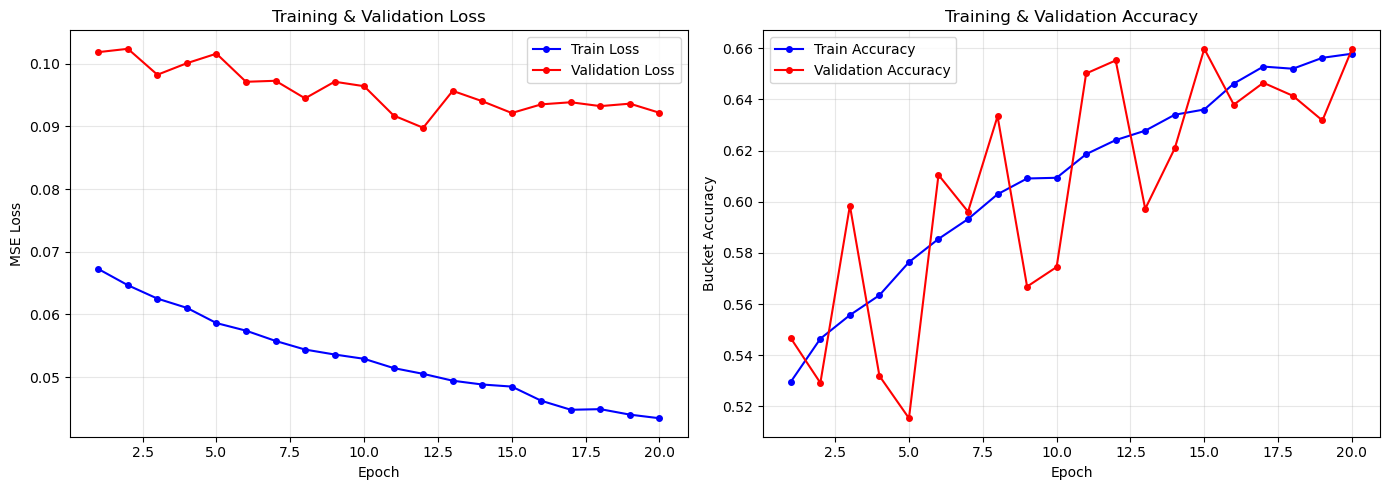

Saved: siamese_lstm_training_curves.png


In [ ]:
# Training Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Loss curves
axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Train Loss', markersize=4)
axes[0].plot(range(1, EPOCHS+1), val_losses, 'r-o', label='Validation Loss', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Accuracy curves
axes[1].plot(range(1, EPOCHS+1), train_accuracies, 'b-o', label='Train Accuracy', markersize=4)
axes[1].plot(range(1, EPOCHS+1), val_accuracies, 'r-o', label='Validation Accuracy', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Bucket Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('siamese_lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: siamese_lstm_training_curves.png")

## Test Evaluation
Loads the best saved model checkpoint and evaluates on the held-out test set:
- Predictions are bucketed into three classes: Unrelated (<0.33), Related (0.33–0.66), Same (>0.66)
- Generates a classification report with precision, recall, and F1 per class
- **Result:** 65.1% accuracy, MSE 0.0936
- Per-class F1: Unrelated (0.68), Related (0.58), Same (0.69)

In [ ]:
# Test Evaluation

# Load best model
model.load_state_dict(torch.load('siamese_lstm_best.pth', map_location=device))
model.eval()
 
all_test_preds = []
all_test_labels = []
 
with torch.no_grad():
    for resume_ids, job_ids, labels in test_loader:
        resume_ids = resume_ids.to(device)
        job_ids = job_ids.to(device)
        labels = labels.to(device)
 
        predictions = model(resume_ids, job_ids)
        all_test_preds.append(predictions)
        all_test_labels.append(labels)
 
all_test_preds = torch.cat(all_test_preds)
all_test_labels = torch.cat(all_test_labels)
 
# Bucket accuracy
test_acc = compute_accuracy(all_test_preds, all_test_labels)
 
# MSE
test_mse = nn.functional.mse_loss(all_test_preds, all_test_labels).item()
 
print("=" * 60)
print("         SIAMESE LSTM BASELINE — TEST RESULTS")
print("=" * 60)
print(f"  Test MSE Loss:       {test_mse:.4f}")
print(f"  Test Bucket Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print("=" * 60)
 
# Bucket-level classification report
buckets = torch.tensor([0.1, 0.5, 0.9], device=all_test_preds.device)
pred_buckets = torch.argmin(torch.abs(all_test_preds.unsqueeze(1) - buckets.unsqueeze(0)), dim=1).cpu().numpy()
true_buckets = torch.argmin(torch.abs(all_test_labels.unsqueeze(1) - buckets.unsqueeze(0)), dim=1).cpu().numpy()
 
label_names = ['Unrelated (0.1)', 'Related (0.5)', 'Same (0.9)']
print("\nClassification Report (Bucketed):")
print(classification_report(true_buckets, pred_buckets, target_names=label_names))

         SIAMESE LSTM BASELINE — TEST RESULTS
  Test MSE Loss:       0.0936
  Test Bucket Accuracy: 0.6511 (65.1%)

Classification Report (Bucketed):
                 precision    recall  f1-score   support

Unrelated (0.1)       0.86      0.56      0.68      1981
  Related (0.5)       0.53      0.63      0.58      1519
     Same (0.9)       0.63      0.76      0.69      2000

       accuracy                           0.65      5500
      macro avg       0.67      0.65      0.65      5500
   weighted avg       0.69      0.65      0.65      5500



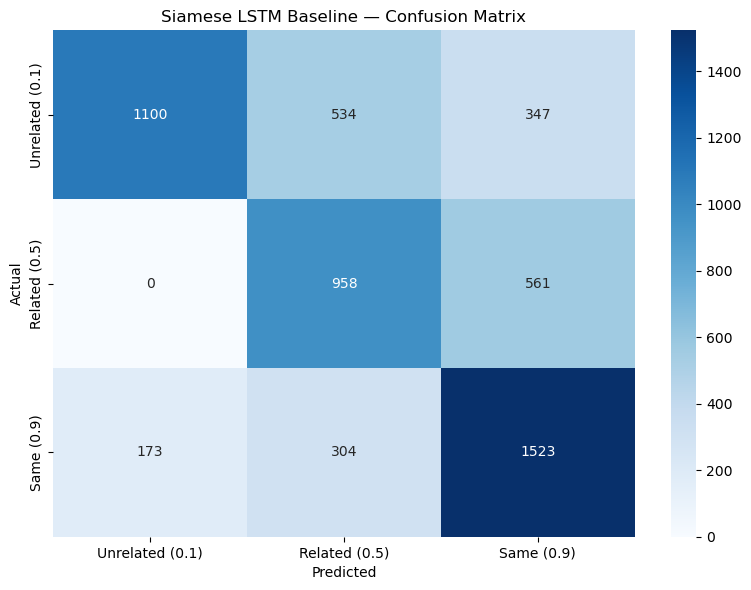

Saved: siamese_lstm_confusion_matrix.png


In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_buckets, pred_buckets)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Siamese LSTM Baseline — Confusion Matrix')
plt.tight_layout()
plt.savefig('siamese_lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: siamese_lstm_confusion_matrix.png")

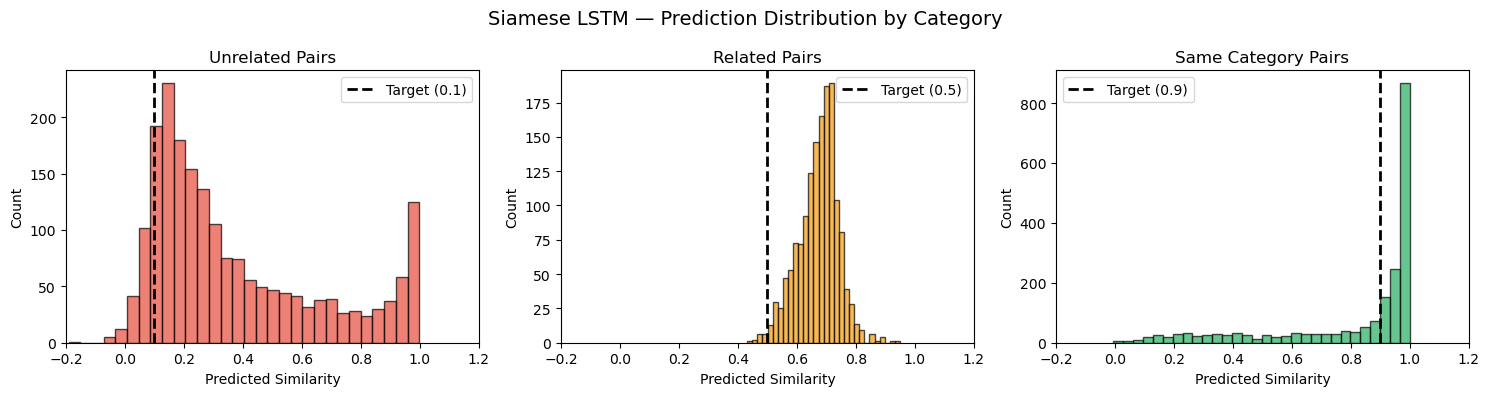

Saved: siamese_lstm_prediction_dist.png


In [17]:
# Prediction Distribution

 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
for i, (label_val, name) in enumerate([(0.1, 'Unrelated'), (0.5, 'Related'), (0.9, 'Same Category')]):
    mask = all_test_labels == label_val
    preds = all_test_preds[mask].cpu().numpy()
    axes[i].hist(preds, bins=30, color=['#e74c3c', '#f39c12', '#27ae60'][i], alpha=0.7, edgecolor='black')
    axes[i].axvline(x=label_val, color='black', linestyle='--', linewidth=2, label=f'Target ({label_val})')
    axes[i].set_xlabel('Predicted Similarity')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{name} Pairs')
    axes[i].legend()
    axes[i].set_xlim(-0.2, 1.2)
 
plt.suptitle('Siamese LSTM — Prediction Distribution by Category', fontsize=14)
plt.tight_layout()
plt.savefig('siamese_lstm_prediction_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: siamese_lstm_prediction_dist.png")

## Save Model and Artifacts
Saves the trained model and supporting files for later use:
- `siamese_lstm_best.pth` — model weights
- Vocabulary mapping (word-to-index) — needed to convert new text into the same integer sequences at inference time

In [ ]:
# Save Model & Artifacts


import json
 
model_artifacts = {
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'max_seq_length': MAX_SEQ_LENGTH,
    'test_accuracy': test_acc,
    'test_mse': test_mse,
    'total_training_pairs': len(pairs),
    'categories': categories,
}
 
with open('siamese_lstm_config.json', 'w') as f:
    json.dump(model_artifacts, f, indent=2)
 
# Save vocabulary mapping
with open('word2idx.json', 'w') as f:
    json.dump(word2idx, f)
 
print("\nSaved model artifacts:")
print("  - siamese_lstm_best.pth      (model weights)")
print("  - siamese_lstm_config.json    (model config)")
print("  - word2idx.json               (vocabulary)")
print("  - siamese_lstm_training_curves.png")
print("  - siamese_lstm_confusion_matrix.png")
print("  - siamese_lstm_prediction_dist.png")
 
print(f"\n{'='*60}")
print(f"  BASELINE SUMMARY")
print(f"{'='*60}")
print(f"  Model:           Siamese LSTM (built from scratch)")
print(f"  Architecture:    Bidirectional LSTM, {NUM_LAYERS} layers")
print(f"  Embedding dim:   {EMBED_DIM}")
print(f"  Hidden dim:      {HIDDEN_DIM} (x2 for bidirectional = {HIDDEN_DIM*2})")
print(f"  Vocab size:      {VOCAB_SIZE:,}")
print(f"  Sequence length: {MAX_SEQ_LENGTH}")
print(f"  Training pairs:  {len(pairs):,}")
print(f"  Parameters:      {total_params:,}")
print(f"  Test Accuracy:   {test_acc*100:.1f}%")
print(f"  Test MSE:        {test_mse:.4f}")
print(f"{'='*60}")


Saved model artifacts:
  - siamese_lstm_best.pth      (model weights)
  - siamese_lstm_config.json    (model config)
  - word2idx.json               (vocabulary)
  - siamese_lstm_training_curves.png
  - siamese_lstm_confusion_matrix.png
  - siamese_lstm_prediction_dist.png

  BASELINE SUMMARY
  Model:           Siamese LSTM (built from scratch)
  Architecture:    Bidirectional LSTM, 2 layers
  Embedding dim:   128
  Hidden dim:      128 (x2 for bidirectional = 256)
  Vocab size:      20,000
  Sequence length: 300
  Training pairs:  54,992
  Parameters:      3,219,456
  Test Accuracy:   65.1%
  Test MSE:        0.0936
